In [8]:
pip install networkx python-igraph matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(42); np.random.seed(42)

Câu 1.1. Tải đồ thị Zachary Karate Club
Tạo đồ thị karate club bằng python-igraph (đã có sẵn) và in ra số đỉnh, số cạnh

In [10]:
import igraph as ig
import numpy as np

g = ig.Graph.Famous('Zachary')

n = g.vcount()
m = g.ecount()
print(f"Số đỉnh (n): {n}, Số cạnh (m): {m}")

Số đỉnh (n): 34, Số cạnh (m): 78


Câu 1.2. Tính các chỉ số thống kê cơ bản
• Bậc trung bình (average degree).
• Hệ số gom cụm trung bình (average clustering coefficient).
• Đường đi trung bình (average path length).

In [11]:
avg_degree = np.mean(g.degree())
avg_clustering = g.transitivity_avglocal_undirected()
avg_path_length = g.average_path_length()

print(f"Bậc trung bình: {avg_degree:.2f}")
print(f"Hệ số gom cụm trung bình: {avg_clustering:.4f}")
print(f"Đường đi trung bình: {avg_path_length:.4f}")

Bậc trung bình: 4.59
Hệ số gom cụm trung bình: 0.5879
Đường đi trung bình: 2.4082


Câu 1.3. Vẽ phân phối bậc (degree distribution)
Vẽ histogram số đỉnh theo bậc. Đỉnh nào có bậc lớn nhất? Theo bạn vì sao?

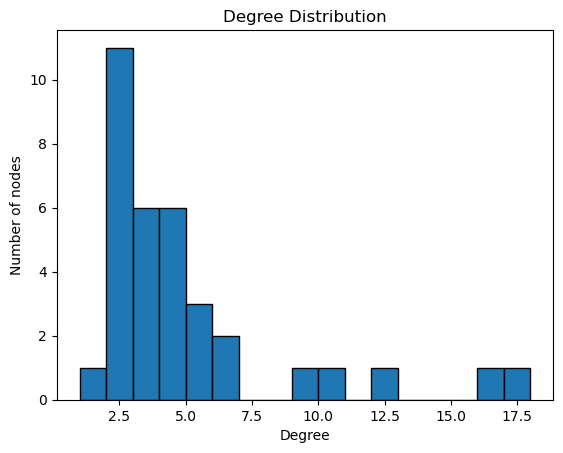

Đỉnh có bậc lớn nhất: 34
Bậc lớn nhất: 17


In [13]:
degrees = g.degree()

plt.hist(degrees, bins=range(min(degrees), max(degrees)+2), edgecolor='black')
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution")
plt.show()

print("Đỉnh có bậc lớn nhất:", np.argmax(degrees)+1)
print("Bậc lớn nhất:", max(degrees))

 Trong các mạng lưới thực tế hoặc mô hình như Barabási-Albert, các đỉnh xuất hiện sớm thường có xu hướng kết nối với nhiều đỉnh mới hơn (cơ chế "ưu tiên kết nối" - preferential attachment). Điều này tạo ra các "hub" (trung tâm) có bậc rất cao so với phần còn lại của mạng lưới

1.4 Vẽ đồ thị Zachary

Câu 2.1 — Mật độ đồ thị

Công thức mật độ:

In [14]:
rho_manual = m / (n*(n-1)/2)
rho_builtin = g.density()

print(rho_manual)
print(rho_builtin)

0.13903743315508021
0.13903743315508021


Câu 2.2 — Modularity của phân hoạch tùy ý

In [15]:
membership_naive = [0]*17 + [1]*17

Q_naive = g.modularity(membership_naive)

print(f"Q (naive partition) = {Q_naive:.4f}")

Q (naive partition) = 0.2433


Câu 2.3 — Internal vs External Density

In [16]:
def community_density(g, membership):
    communities = {}

    for v, c in enumerate(membership):
        communities.setdefault(c, []).append(v)

    for c, nodes in communities.items():

        subgraph = g.subgraph(nodes)

        ns = len(nodes)
        ms = subgraph.ecount()

        # internal density
        delta_int = ms / (ns*(ns-1)/2)

        # external edges
        external_edges = 0

        for node in nodes:
            neighbors = g.neighbors(node)
            for nb in neighbors:
                if nb not in nodes:
                    external_edges += 1

        delta_ext = external_edges / (ns*(g.vcount()-ns))

        print(f"\nCommunity {c}")
        print("δ_int =", round(delta_int,4))
        print("δ_ext =", round(delta_ext,4))

community_density(g, membership_naive)


Community 0
δ_int = 0.2206
δ_ext = 0.0692

Community 1
δ_int = 0.2059
δ_ext = 0.0692


Phần 3 — Thuật toán Edge Betweenness (≈15 phút)
Câu 3.1. Chạy thuật toán Newman–Girvan

In [17]:
dendro_eb = g.community_edge_betweenness(directed=False)

clusters_eb = dendro_eb.as_clustering()

print("Số cộng đồng:", len(clusters_eb))
print("Modularity:", g.modularity(clusters_eb.membership))

Số cộng đồng: 5
Modularity: 0.40129848783694944


In [23]:
!pip install pycairo

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/845.4 kB ? eta -:--:--
   ---------------------------------------- 845.4/845.4 kB 4.7 MB/s eta 0:00:00


Câu 3.2 — Vẽ phân cụm

In [25]:
import igraph as ig
from IPython.display import Image

# Khởi tạo đồ thị và layout
g = ig.Graph.Famous('Zachary')
layout = g.layout_fruchterman_reingold()

# Tính toán phân cụm
dendrogram = g.community_edge_betweenness()
clusters_eb = dendrogram.as_clustering()
colors = clusters_eb.membership

# Vẽ đồ thị và lưu
ig.plot(
    clusters_eb,
    layout=layout,
    vertex_label=[i+1 for i in range(g.vcount())],
    vertex_color=colors,
    vertex_size=25,
    target='edge_betweenness.png'
)

# Hiển thị kết quả
Image('edge_betweenness.png')

AttributeError: Plotting not available; please install pycairo or cairocffi

Câu 3.3 — Vẽ dendrogram

In [27]:
ig.plot(dendrogram, target='dendrogram_eb.png')

AttributeError: Plotting not available; please install pycairo or cairocffi